In [1]:
# import zipfile
# import torch
# import numpy as np
# import tempfile
# import os
# from tqdm import tqdm  # для отображения прогресса (можно установить pip install tqdm)

# def load_points_from_zip(zip_path, max_tensors=None, verbose=True):
#     """
#     Загружает все .pt файлы из zip-архива.
#     Каждый файл должен содержать тензор формы [16, 32, 32].
#     Преобразует каждый тензор в набор точек (1024, 16) путём reshape.
#     Возвращает массив numpy формы (N * 1024, 16), где N – число обработанных тензоров.

#     Параметры:
#         zip_path: путь к zip-файлу
#         max_tensors: если указано, загрузить только первые max_tensors файлов (для отладки)
#         verbose: печатать прогресс
#     """
#     all_points = []

#     with zipfile.ZipFile(zip_path, 'r') as z:
#         # Получаем все .pt файлы и сортируем для воспроизводимости порядка
#         pt_files = sorted([f for f in z.namelist() if f.endswith('.pt')])
#         if max_tensors is not None:
#             pt_files = pt_files[:max_tensors]

#         if verbose:
#             print(f"Найдено {len(pt_files)} .pt файлов в {zip_path}")
#             iterator = tqdm(pt_files, desc="Обработка файлов")
#         else:
#             iterator = pt_files

#         for file_name in iterator:
#             with z.open(file_name) as f:
#                 # Сохраняем во временный файл, так как torch.load требует файловый объект
#                 with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as tmp:
#                     tmp.write(f.read())
#                     tmp_path = tmp.name
#                 try:
#                     tensor = torch.load(tmp_path, map_location='cpu')
#                     # Проверяем форму
#                     if not (isinstance(tensor, torch.Tensor) and tensor.shape == (16, 32, 32)):
#                         if verbose:
#                             print(f"Предупреждение: файл {file_name} имеет форму {tensor.shape}, пропускаем.")
#                         continue
#                     # Преобразуем: (16, 32, 32) -> (1024, 16)
#                     points = tensor.permute(1, 2, 0).reshape(-1, 16).numpy()
#                     # points.shape = (1024, 16)
#                     all_points.append(points)
#                 finally:
#                     os.unlink(tmp_path)  # удаляем временный файл

#     if not all_points:
#         raise ValueError(f"Не удалось загрузить ни одного подходящего тензора из {zip_path}")

#     # Объединяем все точки в один массив
#     final_points = np.concatenate(all_points, axis=0)  # форма (N*1024, 16)
#     if verbose:
#         print(f"Итоговая форма облака точек: {final_points.shape}")
#     return final_points

# # Пример использования
# points_1 = load_points_from_zip('part_1.zip')
# points_2 = load_points_from_zip('part_2.zip') # форма (10_240_000, 16)

In [2]:
import zipfile
import torch
import numpy as np
import tempfile
import os
import random
from tqdm import tqdm

def load_random_tensors(zip_path, n_tensors=100, random_seed=72):
    """
    Случайно выбирает n_tensors .pt файлов из zip-архива,
    загружает каждый тензор [16, 32, 32], преобразует в (1024, 16)
    и объединяет все точки в один массив.

    Параметры:
        zip_path (str): путь к zip-файлу
        n_tensors (int): количество случайных тензоров
        random_seed (int): для воспроизводимости

    Возвращает:
        np.ndarray формы (n_tensors * 1024, 16)
    """
    # Получаем список всех .pt файлов в архиве
    with zipfile.ZipFile(zip_path, 'r') as z:
        pt_files = [f for f in z.namelist() if f.endswith('.pt')]
        if len(pt_files) < n_tensors:
            raise ValueError(f"В архиве только {len(pt_files)} .pt файлов, запрошено {n_tensors}")

        # random.seed(random_seed)
        chosen_files = random.sample(pt_files, n_tensors)

    all_points = []

    for file_name in tqdm(chosen_files, desc=f"Загрузка {n_tensors} тензоров"):
        with zipfile.ZipFile(zip_path, 'r') as z:  # открываем каждый раз, или можно открыть один раз вне цикла, но тогда нужно перематывать? Лучше открыть один раз и читать.
            with z.open(file_name) as f:
                with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as tmp:
                    tmp.write(f.read())
                    tmp_path = tmp.name
                try:
                    tensor = torch.load(tmp_path, map_location='cpu')
                    if not (isinstance(tensor, torch.Tensor) and tensor.shape == (16, 32, 32)):
                        print(f"Предупреждение: файл {file_name} имеет форму {tensor.shape}, пропускаем.")
                        continue
                    points = tensor.permute(1, 2, 0).reshape(-1, 16).numpy()
                    all_points.append(points)
                finally:
                    os.unlink(tmp_path)

    if not all_points:
        raise ValueError("Не удалось загрузить ни одного корректного тензора")

    return np.concatenate(all_points, axis=0)

# Пример использования
points_from_one = load_random_tensors('part_1.zip', n_tensors=200)
print(f"Итоговая форма: {points_from_one.shape}")  # (102400, 16)

Загрузка 200 тензоров:   0%|          | 0/200 [00:00<?, ?it/s]/tmp/job-3658169/ipykernel_197971/873851410.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor = torch

Итоговая форма: (204800, 16)


In [3]:
# import numpy as np

# def random_landmarks(points, n_landmarks, random_seed=42):
#     """
#     points: массив (N, D)
#     n_landmarks: количество ландмарок
#     возвращает индексы случайно выбранных точек
#     """
#     rng = np.random.default_rng(random_seed)
#     indices = rng.choice(len(points), size=n_landmarks, replace=False)
#     return indices

# # Использование
# landmark_idx = random_landmarks(points_1, 500)
# landmarks = points_1[landmark_idx]

In [4]:
# from google.colab import drive
# drive.mount('/content/gdrive')

In [5]:
def D(point1, point2):
    # евклидова метрика
    return np.linalg.norm(np.array(point1) - np.array(point2))

def maxmin_landmarks1(Z, n):

    # Инициализация списка опорных точек
    landmarks = []

    # Случайный выбор первой опорной точки
    l1 = Z[np.random.choice(len(Z))]
    landmarks.append([float(coord) for coord in l1])

    while len(landmarks) < n:
        # Вычисляем минимальное расстояние до уже выбранных опорных точек
        min_distances = np.array([min(D(z, l) for l in landmarks) for z in Z])

        # Находим точку, которая максимизирует минимальное расстояние
        next_landmark_index = np.argmax(min_distances)
        landmarks.append([float(coord) for coord in Z[next_landmark_index]])

    return np.array(landmarks)

In [6]:
# Ячейка 1: функция отбора плотных точек (если ещё не определена)
from sklearn.neighbors import NearestNeighbors
import numpy as np

def select_dense_points(points, n_select=300, k=15):
    """
    Возвращает n_select точек с наименьшим расстоянием до k-го соседа,
    а также их индексы в исходном массиве.
    """
    nn = NearestNeighbors(n_neighbors=k, metric='euclidean', n_jobs=-1)
    nn.fit(points)
    distances, _ = nn.kneighbors(points)
    kth_dist = distances[:, k-1]
    sorted_idx = np.argsort(kth_dist)
    selected_idx = sorted_idx[:n_select]
    return points[selected_idx], selected_idx

# Ячейка 2: функция maxmin_landmarks (из вашего кода, но адаптированная для возврата индексов)
def maxmin_landmarks(Z, n, random_seed=42):
    """
    Возвращает n ландмарок, выбранных методом максимин,
    а также их индексы в исходном массиве Z.
    """
    np.random.seed(random_seed)
    n_points = len(Z)
    # Первая ландмарка случайно
    first_idx = np.random.choice(n_points)
    landmarks_idx = [first_idx]
    landmarks = [Z[first_idx]]

    while len(landmarks) < n:
        # Вычисляем минимальное расстояние до уже выбранных ландмарок
        min_dists = np.array([min(np.linalg.norm(z - l) for l in landmarks) for z in Z])
        # Находим точку с максимальным минимальным расстоянием
        next_idx = np.argmax(min_dists)
        landmarks_idx.append(next_idx)
        landmarks.append(Z[next_idx])

    return np.array(landmarks), np.array(landmarks_idx)


In [7]:
# import zipfile
# import torch
# import numpy as np
# import tempfile
# import os
# import random

# def sample_random_tensor_points(zip_path):
#     """
#     Из zip-архива выбирает случайный .pt файл,
#     загружает тензор [16, 32, 32] и преобразует в массив точек (1024, 16).

#     Параметры:
#         zip_path (str): путь к zip-файлу с .pt тензорами

#     Возвращает:
#         np.ndarray формы (1024, 16) — точки из одного случайного тензора
#     """
#     with zipfile.ZipFile(zip_path, 'r') as z:
#         # Получаем список всех .pt файлов
#         pt_files = [f for f in z.namelist() if f.endswith('.pt')]
#         if not pt_files:
#             raise ValueError("В архиве нет .pt файлов")

#         # Случайный выбор файла
#         chosen = random.choice(pt_files)
#         print(f"Выбран файл: {chosen}")

#         # Чтение файла
#         with z.open(chosen) as f:
#             # Сохраняем во временный файл, так как torch.load требует файловый объект
#             with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as tmp:
#                 tmp.write(f.read())
#                 tmp_path = tmp.name

#             try:
#                 # Загружаем тензор
#                 tensor = torch.load(tmp_path, map_location='cpu')

#                 # Проверяем форму
#                 if not (isinstance(tensor, torch.Tensor) and tensor.shape == (16, 32, 32)):
#                     raise ValueError(f"Файл {chosen} имеет форму {tensor.shape}, ожидалась (16, 32, 32)")

#                 # Преобразуем: (16, 32, 32) -> (32, 32, 16) -> (1024, 16)
#                 points = tensor.permute(1, 2, 0).reshape(-1, 16).numpy()

#                 return points

#             finally:
#                 # Удаляем временный файл
#                 os.unlink(tmp_path)

# Если хотите зафиксировать случайность для воспроизводимости:
# random.seed(42)
# points_from_one_fixed = sample_random_tensor_points('/content/gdrive/MyDrive/дз матстат/part_1.zip')

In [8]:
# # Пример использования
# points_from_one = sample_random_tensor_points('part_2.zip')
# print("Форма полученного массива:", points_from_one.shape)  # (1024, 16)

In [9]:
from sklearn.decomposition import PCA

In [10]:
points_from_one

array([[ 3.203125  , -0.6015625 ,  2.171875  , ...,  0.9140625 ,
         0.546875  , -1.765625  ],
       [-0.18359375, -5.15625   ,  0.67578125, ...,  1.03125   ,
        -0.41796875,  0.39257812],
       [ 2.40625   , -5.15625   ,  1.5390625 , ...,  1.921875  ,
        -2.875     , -0.14257812],
       ...,
       [ 1.0859375 , -3.609375  ,  1.2734375 , ...,  0.39257812,
        -0.26757812,  2.703125  ],
       [ 1.125     , -1.9765625 , -0.41796875, ...,  0.09765625,
         1.2421875 ,  2.65625   ],
       [-0.06298828, -1.5703125 ,  0.43164062, ...,  0.8046875 ,
         0.9609375 ,  1.09375   ]], dtype=float32)

In [11]:
# pca = PCA(n_components=3)
# points_pca_one = pca.fit_transform(points_from_one)

In [12]:
# maxmin_points = maxmin_landmarks(points_pca_one, 100)

In [13]:
# %pip install gudhi

In [14]:
# Ячейка: нормализация на сферу
# points_from_one - исходный массив (1024, 16)
# Вычисляем нормы
norms = np.linalg.norm(points_from_one, axis=1, keepdims=True)
# Защита от деления на ноль (если есть нулевые векторы, оставляем их как есть, но на сфере они будут проблемой; лучше заменить на малый вектор или удалить)
# Для простоты будем считать, что нулевых нет.
norms[norms == 0] = 1  # на случай, если нулевые векторы встретятся
points_on_sphere = points_from_one / norms
points_on_sphere

array([[ 0.45429856, -0.08531948,  0.30803657, ...,  0.1296413 ,
         0.07756317, -0.25041822],
       [-0.02467084, -0.6928833 ,  0.0908097 , ...,  0.13857666,
        -0.05616554,  0.05275361],
       [ 0.31817585, -0.68180543,  0.20350859, ...,  0.25412747,
        -0.38015816, -0.01885295],
       ...,
       [ 0.15036179, -0.49976367,  0.17632355, ...,  0.05435741,
        -0.03704958,  0.37428188],
       [ 0.16903049, -0.2969772 , -0.06279952, ...,  0.01467279,
         0.18663783,  0.39909977],
       [-0.01059635, -0.26416942,  0.07261374, ...,  0.1353704 ,
         0.16165592,  0.18399861]], dtype=float32)

Отобрано 20000 плотных точек на сфере
Выбрано 40 ландмарок
Ландмарок: 40, свидетелей: 19960


/home/talodochkin/.conda/envs/hg/lib/python3.11/site-packages/gudhi/persistence_graphical_tools.py:134: UserWarning: usetex mode requires dvipng.
  warnings.warn("usetex mode requires dvipng.")


<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

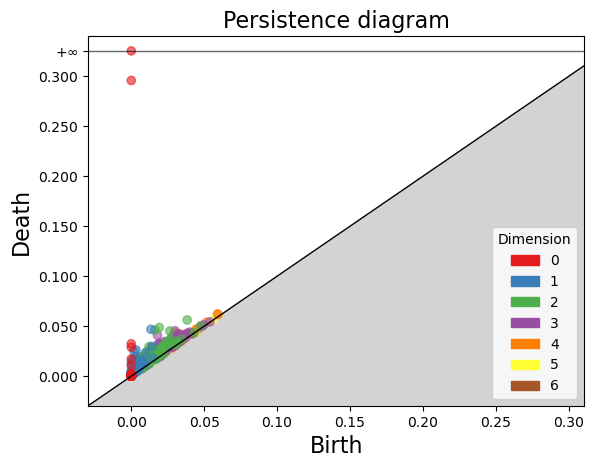

In [15]:


# # Далее работаем с points_on_sphere вместо points_from_one
# pca = PCA(n_components=0.95)
# points_pca_one = pca.fit_transform(points_on_sphere)
# print(points_pca_one.shape)

# 1. Выбираем 300 самых плотных точек из нормализованных
dense_300, idx_dense = select_dense_points(points_on_sphere, n_select=20000, k=80)
print(f"Отобрано {len(dense_300)} плотных точек на сфере")

# 2. Из этих 300 выбираем 20 ландмарок методом максимин
landmarks, landmark_indices_in_dense = maxmin_landmarks(dense_300, 40)
print(f"Выбрано {len(landmarks)} ландмарок")

# 3. Свидетели — все остальные точки из тех же 300 (исключая ландмарки)
all_dense_indices = np.arange(len(dense_300))
witness_indices_in_dense = np.setdiff1d(all_dense_indices, landmark_indices_in_dense)
witnesses = dense_300[witness_indices_in_dense]

print(f"Ландмарок: {len(landmarks)}, свидетелей: {len(witnesses)}")

# 4. Строим EuclideanWitnessComplex
import gudhi
witness_complex = gudhi.EuclideanStrongWitnessComplex(landmarks=landmarks, witnesses=witnesses)
simplex_tree = witness_complex.create_simplex_tree(max_alpha_square=1.6)

# 5. Вычисляем и визуализируем персистентность
diag = simplex_tree.persistence()
gudhi.plot_persistence_diagram(diag)

In [16]:
impoj
import gudhi
import numpy as np
import matplotlib.pyplot as plt
dense_301, idx_dense1 = select_dense_points(points_on_sphere, n_select=400, k=12)
maxmin = maxmin_landmarks1(dense_301, 90)
print(maxmin)
rips_complex = gudhi.RipsComplex(points=maxmin)
simplex_tree = rips_complex.create_simplex_tree(max_dimension=4)

# Вычисление гомологических диаграмм
diagrams = simplex_tree.persistence()

print(diagrams)

# Визуализация баркодов
gudhi.plot_persistence_diagram(diagrams)
plt.title("Persistence Diagram")
plt.show()

gudhi.plot_persistence_barcode(diagrams)
plt.title("Persistence Barcode")
plt.show()


NameError: name 'impoj' is not defined

In [ ]:
points_from_two = sample_random_tensor_points('/content/gdrive/MyDrive/дз матстат/part_2.zip')

In [ ]:
points_from_one.shape

In [ ]:
points_from_two

In [ ]:
maxmin_points_2 = maxmin_landmarks(points_from_two, 100)

In [ ]:
import gudhi
import numpy as np
import matplotlib.pyplot as plt
rips_complex = gudhi.RipsComplex(points=maxmin_points_2)
simplex_tree = rips_complex.create_simplex_tree(max_dimension=5)

# Вычисление гомологических диаграмм
diagrams = simplex_tree.persistence()

print(diagrams)

# Визуализация баркодов
gudhi.plot_persistence_diagram(diagrams)
plt.title("Persistence Diagram")
plt.show()

gudhi.plot_persistence_barcode(diagrams)
plt.title("Persistence Barcode")
plt.show()
